In [1]:
from default_libs import *

In [2]:
df=pd.read_csv("C:\\Users\\lette\\Data Analytics\\Data Visualization\\Zomato-data-.csv")

In [3]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [4]:
def clean_rate(value):
    value=str(value).split('/')
    value=value[0]
    return float(value)
    
df['rate']=df['rate'].apply(clean_rate)

In [5]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [6]:
numerical_data=['rate','votes','approx_cost(for two people)']
nominal_data=['online_order','book_table']

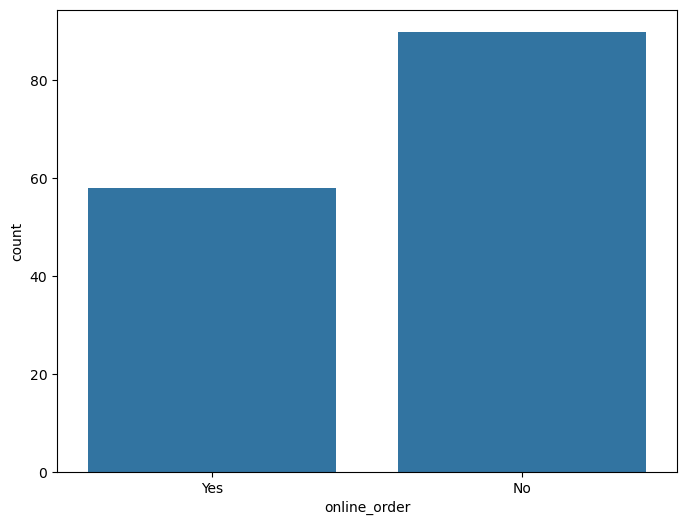

In [7]:
plt.figure(figsize=(8,6))
sns.countplot(x=df['online_order'])
plt.show()

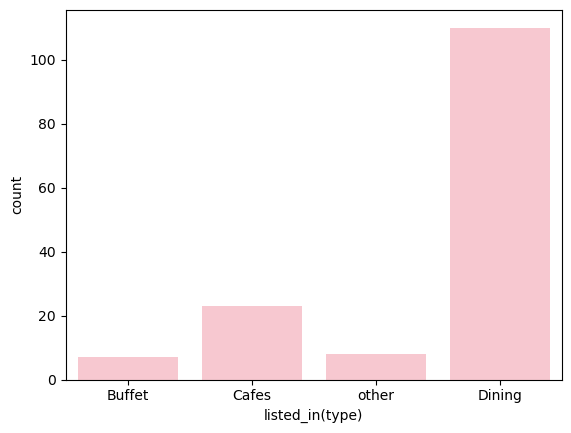

In [11]:
sns.countplot(x=df['listed_in(type)'],color='pink')
plt.show()

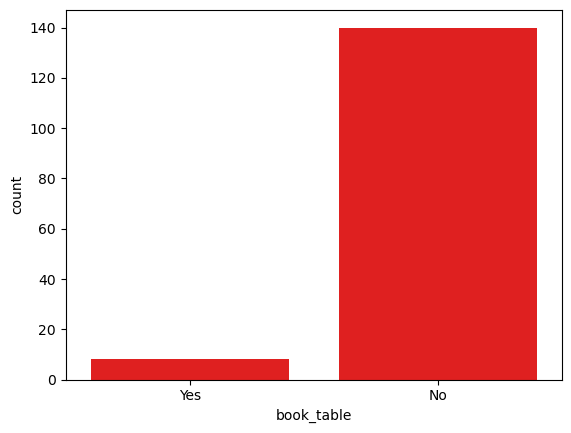

In [35]:
sns.countplot(x=df['book_table'],color='red')
plt.show()

In [8]:
df.groupby('listed_in(type)')['votes'].sum()

listed_in(type)
Buffet     3028
Cafes      6434
Dining    20363
other      9367
Name: votes, dtype: int64

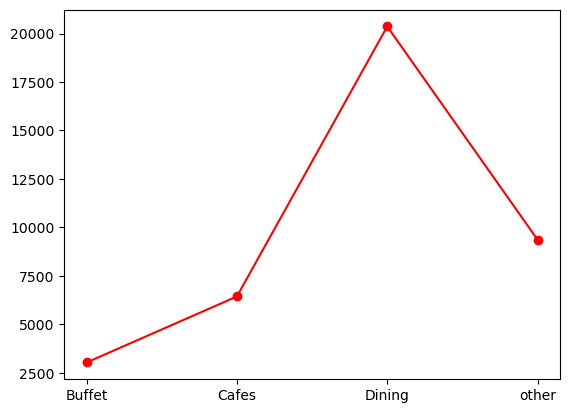

In [12]:
type_and_votes=df.groupby('listed_in(type)')['votes'].sum()
result=pd.DataFrame({'votes':type_and_votes})
plt.plot(result,c='red',marker='o')
plt.show()

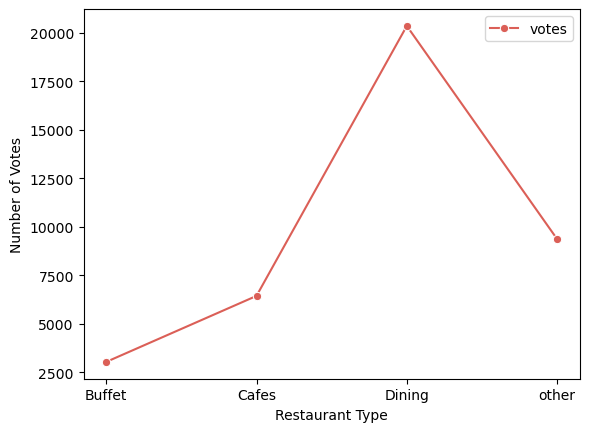

In [57]:
type_and_votes=df.groupby('listed_in(type)')['votes'].sum()
result=pd.DataFrame({'votes':type_and_votes})
sns.lineplot(result,palette='hls',markers='o')
plt.xlabel('Restaurant Type')
plt.ylabel('Number of Votes')
plt.savefig("restaurant_votes.jpg",dpi=300)
plt.show()

In [13]:
df['votes'].max()

4884

In [14]:
max_votes=df['votes'].max()
restaurant_with_most_likes=df.loc[df['votes']==max_votes,'name']
print(f"Highest voted Restaurant is :{restaurant_with_most_likes} with {max_votes} votes")

Highest voted Restaurant is :38    Empire Restaurant
Name: name, dtype: object with 4884 votes


In [17]:
df['votes'].nlargest(5)

38    4884
86    4401
7     2556
44    2556
65    1720
Name: votes, dtype: int64

In [22]:
top_5_votes=df['votes'].nlargest(5).index
top_voted_restaurants=df.loc[top_5_votes,'name']
print(top_voted_restaurants)

38    Empire Restaurant
86        Meghana Foods
7                Onesta
44               Onesta
65          Kabab Magic
Name: name, dtype: object


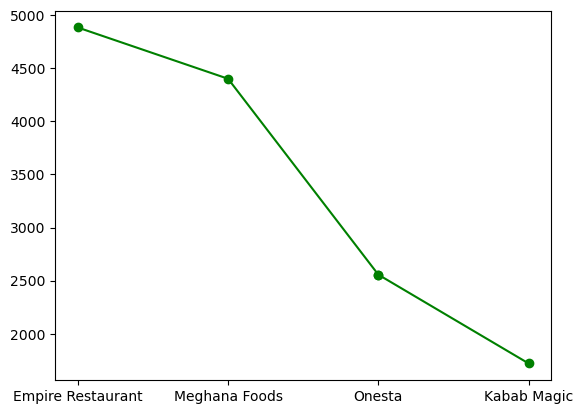

In [29]:
top_5_votes=df['votes'].nlargest(5).index
top_voted_restaurants=df.loc[top_5_votes,['name','votes']]
plt.plot(top_voted_restaurants['name'],top_voted_restaurants['votes'],c="green",marker="o")
plt.show()

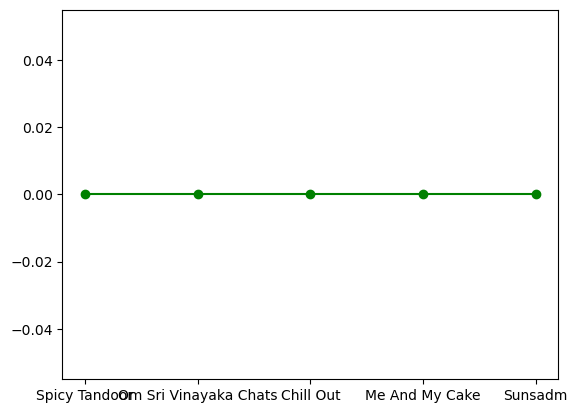

In [33]:
top_5_votes=df['votes'].nsmallest(5).index
top_voted_restaurants=df.loc[top_5_votes,['name','votes']]
plt.plot(top_voted_restaurants['name'],top_voted_restaurants['votes'],c="green",marker="o")
plt.show()